In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mlflow
import mlflow.xgboost

sns.set_theme(style="whitegrid")

# Dynamic root path resolution
NOTEBOOK_DIR = Path(os.getcwd())
ROOT_DIR = NOTEBOOK_DIR.parents[1]

PROJECT_DIR = ROOT_DIR / "project-1-credit-card-fraud"
DATA_PATH = PROJECT_DIR / "data" / "processed_features.parquet"
DB_PATH = ROOT_DIR / "mlflow.db"

# Establish secure backend connections
sqlite_uri = f"sqlite:///{DB_PATH.resolve()}"
mlflow.set_tracking_uri(sqlite_uri)

# Fetch latest run ID
experiment = mlflow.get_experiment_by_name("credit_card_fraud_governance")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], order_by=["attributes.start_time DESC"])
latest_run_id = runs.iloc[0]["run_id"]

# Load model binary and data
model = mlflow.xgboost.load_model(f"runs:/{latest_run_id}/model")
df = pd.read_parquet(DATA_PATH)
X = df.drop(columns=['Class'])

print("✅ Observability environment and model payload ready.")

/home/satya-linux/miniconda3/envs/mlops-lab/lib/python3.12/site-packages/pydantic/_internal/_fields.py:151: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/satya-linux/miniconda3/envs/mlops-lab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Observability environment and model payload ready.


🧪 Simulating a live production batch with feature distribution drift...


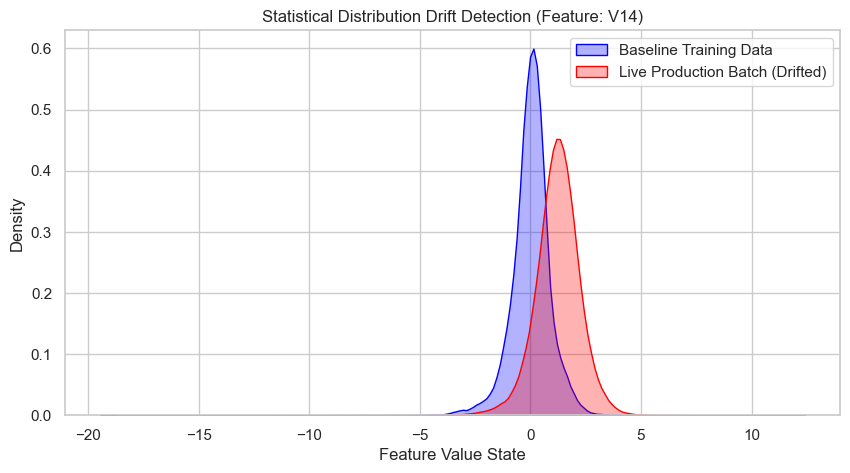

In [4]:
# Apply distribution shift globally to simulate realistic adversarial shift
print("🧪 Simulating a live production batch with feature distribution drift...")

baseline_v14 = X['V14'].to_numpy()
# Shift the entire distribution out of its training bounds
live_v14 = baseline_v14 + np.random.normal(1.2, 0.5, size=len(baseline_v14))

# Plot distribution shift
plt.figure(figsize=(10, 5))
sns.kdeplot(baseline_v14, label='Baseline Training Data', color='blue', fill=True, alpha=0.3)
sns.kdeplot(live_v14, label='Live Production Batch (Drifted)', color='red', fill=True, alpha=0.3)
plt.title("Statistical Distribution Drift Detection (Feature: V14)")
plt.xlabel("Feature Value State")
plt.ylabel("Density")
plt.legend()
plt.show()

In [5]:
# Handle identical percentiles safely for concentrated distributions
def calculate_psi(baseline: np.ndarray, target: np.ndarray, num_bins: int = 10) -> float:
    quantiles = np.linspace(0, 100, num_bins + 1)
    bins = np.percentile(baseline, quantiles)
    
    # Inject slight noise to break duplicate bin boundaries
    if len(np.unique(bins)) < len(bins):
        bins = np.linspace(baseline.min(), baseline.max(), num_bins + 1)
        
    bins[0] -= 1e-5
    bins[-1] += 1e-5
    
    baseline_counts, _ = np.histogram(baseline, bins=bins)
    target_counts, _ = np.histogram(target, bins=bins)
    
    baseline_ratios = np.where(baseline_counts / len(baseline) == 0, 1e-4, baseline_counts / len(baseline))
    target_ratios = np.where(target_counts / len(target) == 0, 1e-4, target_counts / len(target))
    
    return np.sum((target_ratios - baseline_ratios) * np.log(target_ratios / baseline_ratios))

psi_metric = calculate_psi(baseline_v14, live_v14)
print(f"📊 Calculated PSI Value: {psi_metric:.4f}")

if psi_metric < 0.1:
    print("🟢 Status: STABLE. No significant distribution shift detected.")
elif 0.1 <= psi_metric < 0.25:
    print("🟡 Status: WARNING. Moderate drift detected. Schedule pipeline check.")
else:
    print("🔴 Status: ALERT! Significant Data Drift detected. Trigger Automated Retraining.")

📊 Calculated PSI Value: 1.7066
🔴 Status: ALERT! Significant Data Drift detected. Trigger Automated Retraining.
